### Exercise Report for Course: Stochastic Simulation

0. Library Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import geom
from scipy.stats.sampling import DiscreteAliasUrn
from scipy.stats import chisquare
import time
import random
import math
import simpy

#### Day 3 Exercise - Ferry Blocking

if all ferries are busy → the customer is blocked and lost forever. What is the rate of blockage, given the parameters and the capacity (M)?

In [2]:
# inter-arrival time generator helper functions
def interarrival_poisson(lambda_a):
    return np.random.exponential(1.0 / lambda_a)

def interarrival_erlang(k, mean):
    lam = k / mean
    return np.random.gamma(shape=k, scale=1/lam)

def interarrival_hyperexp(p1, lam1, p2, lam2):
    if np.random.rand() < p1:
        return np.random.exponential(1/lam1)
    else:
        return np.random.exponential(1/lam2)


# Service time helper functions, to make it easier to replace distributions in the next cell

def service_time_exponential(mean):
    return np.random.exponential(mean)

def service_time_pareto(k, beta):
    return (np.random.pareto(k) + 1) * beta

def service_time_pareto_low_k():
    k = 1.05
    beta = 8 * (k - 1) / k
    return service_time_pareto(k, beta)

def service_time_pareto_high_k():
    k = 2.05
    beta = 8 * (k - 1) / k
    return service_time_pareto(k, beta)


def service_time_deterministic(value):
    return value

def service_time_uniform(a, b):
    return np.random.uniform(a, b)


def get_service_time(model):
    if model == "exponential":
        return service_time_exponential(MEAN_SERVICE_TIME[selected_time])

    elif model == "pareto_low_k":
        return service_time_pareto_low_k()

    elif model == "pareto_high_k":
        return service_time_pareto_high_k()

    elif model == "uniform":
        return service_time_uniform(2, 14)

    else:
        raise ValueError(f"Unknown service time model: {model}")

# Helper function for selecting the inter-arrival time model
def get_interarrival_time(model):
    if model == "poisson":
        return interarrival_poisson(LAMBDA_A)

    elif model == "erlang":
        return interarrival_erlang(k=3, mean=1.0)

    elif model == "hyperexp":
        return interarrival_hyperexp(
            p1=0.8, lam1=0.8333,
            p2=0.2, lam2=5.0
        )
    else:
        raise ValueError(f"Unknown arrival model: {model}")

In [16]:
# Parameters
M = 10  # Capacity
MEAN_SERVICE_TIME = [6, 8, 12]  # Mean service time, original time is 8 time units
LAMBDA_A = 1.0  # Arrival rate
TARGET_CUSTOMERS = 10_000  # Customers per simulation run
REPLICATIONS = 10  # Number of simulation runs for CI calculation
ARRIVAL_MODEL = 'poisson'
SERVICE_MODEL = 'exponential'
selected_time = 1  # Index for mean service time (0: 6, 1: 8, 2: 10)


# customer process
def customer_process(env, name, system, stats):
    if system.count < system.capacity:
        with system.request() as req:
            yield req
            service_time = get_service_time(SERVICE_MODEL)
            stats["service_times"].append(service_time) 
            yield env.timeout(service_time)
    else:
        stats["blocked"] += 1

# arrival generator
def arrival_generator(env, system, stats, model):
    customer_id = 0
    while customer_id < TARGET_CUSTOMERS:

        inter_arrival = get_interarrival_time(model)
        yield env.timeout(inter_arrival)

        customer_id += 1
        stats["total"] += 1
        env.process(customer_process(env, f"C_{customer_id}", system, stats))

# single simulation script
def run_single_simulation(seed, model):
    np.random.seed(seed)
    env = simpy.Environment()
    system = simpy.Resource(env, capacity=M)

    stats = {"total": 0, "blocked": 0, "service_times": []}

    env.process(arrival_generator(env, system, stats, model))
    env.run(until=TARGET_CUSTOMERS * 2)

    blocked_fraction = stats["blocked"] / stats["total"]
    empirical_mean_service = np.mean(stats["service_times"])

    return blocked_fraction, empirical_mean_service

blocked_fractions = []
empirical_means = []

for i in range(REPLICATIONS):
    fraction, emp_mean = run_single_simulation(seed=42 + i, model=ARRIVAL_MODEL)
    blocked_fractions.append(fraction)
    empirical_means.append(emp_mean)

    print(f"Replication {i+1}: Blocked = {fraction:.6f}, Empirical Mean Service = {emp_mean:.4f}")


# Calculate Sample Mean and Standard Deviation
mean_blocked = np.mean(blocked_fractions)
std_blocked = np.std(blocked_fractions, ddof=1)
var_blocked = np.var(blocked_fractions, ddof=1)


# Calculate 95% Confidence Interval using t-distribution
confidence = 0.95
df = REPLICATIONS - 1
t_crit = 2.262  # Critical value for df=9, 95% confidence (two-tailed)
margin_of_error = t_crit * (std_blocked / math.sqrt(REPLICATIONS))

ci_low = max(0, mean_blocked - margin_of_error)
ci_high = mean_blocked + margin_of_error

# THEORETICAL ERLANG B (For Comparison)
traffic_A = LAMBDA_A * MEAN_SERVICE_TIME[selected_time]
numerator = (traffic_A**M) / math.factorial(M)
denominator = sum((traffic_A**i) / math.factorial(i) for i in range(M + 1))
theoretical_B = numerator / denominator

# Summary from the simulation
print("\n" + "=" * 40)
print(f"Final Report: Arrival Model - {ARRIVAL_MODEL},  Mean Service Time - {MEAN_SERVICE_TIME[selected_time]}, Service Model - {SERVICE_MODEL}")
print("=" * 40)
print(f"Simulation Mean Service Time:       {np.array(np.mean(empirical_means)).mean():.6f}")
print(f"Theoretical Erlang B Blocked Fraction: {theoretical_B:.6f}")
print(f"Simulation Mean Blocked Fraction:    {mean_blocked:.6f}")
print(f"Sample Variance (Blocked Fraction): {var_blocked:.8f}")
print(f"95% Confidence Interval (CI):       [{ci_low:.6f}, {ci_high:.6f}]")
print("=" * 40)

Replication 1: Blocked = 0.120200, Empirical Mean Service = 7.9160
Replication 2: Blocked = 0.112600, Empirical Mean Service = 7.9747
Replication 3: Blocked = 0.125400, Empirical Mean Service = 8.0773
Replication 4: Blocked = 0.125500, Empirical Mean Service = 8.0763
Replication 5: Blocked = 0.125900, Empirical Mean Service = 7.9695
Replication 6: Blocked = 0.116200, Empirical Mean Service = 7.9085
Replication 7: Blocked = 0.122200, Empirical Mean Service = 8.0289
Replication 8: Blocked = 0.127300, Empirical Mean Service = 7.9647
Replication 9: Blocked = 0.116700, Empirical Mean Service = 7.8979
Replication 10: Blocked = 0.111900, Empirical Mean Service = 7.9161

Final Report: Arrival Model - poisson,  Mean Service Time - 8, Service Model - exponential
Simulation Mean Service Time:       7.972995
Theoretical Erlang B Blocked Fraction: 0.121661
Simulation Mean Blocked Fraction:    0.120390
Sample Variance (Blocked Fraction): 0.00003295
95% Confidence Interval (CI):       [0.116284, 0.12

### Part 5 of Exercise 5 (Control Variates to reduce the variance of the estimator)

In [17]:
# Parameters
M = 10  # Capacity
MEAN_SERVICE_TIME = [6, 8, 12]  # Mean service time, original time is 8 time units
LAMBDA_A = 1.0  # Arrival rate
TARGET_CUSTOMERS = 10_000  # Customers per simulation run
REPLICATIONS = 10  # Number of simulation runs for CI calculation
ARRIVAL_MODEL = 'poisson'
SERVICE_MODEL = 'exponential'
selected_time = 1  # Index for mean service time (0: 6, 1: 8, 2: 10)


blocked_fractions_control = []
empirical_means_control = []

for i in range(REPLICATIONS):
    fraction, emp_mean = run_single_simulation(seed=42 + i, model=ARRIVAL_MODEL)
    blocked_fractions_control.append(fraction)
    empirical_means_control.append(emp_mean)

    print(f"Replication {i+1}: Blocked = {fraction:.6f}, Empirical Mean Service = {emp_mean:.4f}")

# Control variate estimator

X = np.array(blocked_fractions_control)
Z = np.array(empirical_means_control)
mu_Z = MEAN_SERVICE_TIME[selected_time]   # known true mean

# Covariance and variance
cov_XZ = np.cov(X, Z, ddof=1)[0, 1]
var_Z  = np.var(Z, ddof=1)

# Optimal c
c = - cov_XZ / var_Z
# Adjusted estimator
Y = X + c * (Z - mu_Z)

# Variances
var_X = np.var(X, ddof=1)
var_Y = np.var(Y, ddof=1)

# Statistics
mean_Y = np.mean(Y)
std_Y  = np.std(Y, ddof=1)
SE_Y   = std_Y / np.sqrt(REPLICATIONS)

ci_low_Y  = mean_Y - t_crit * SE_Y
ci_high_Y = mean_Y + t_crit * SE_Y

print("\nCONTROL VARIATE RESULTS")
print(f"Original Variance (X):           {var_X:.8f}")
print(f"Adjusted Variance (Y):           {var_Y:.8f}")
print(f"Variance Reduction Factor:       {var_X / var_Y:.2f}x")
print(f"Adjusted Mean Blocked Fraction:  {mean_Y:.6f}")
print(f"95% CI:                          [{ci_low_Y:.6f}, {ci_high_Y:.6f}]")

Replication 1: Blocked = 0.120200, Empirical Mean Service = 7.9160
Replication 2: Blocked = 0.112600, Empirical Mean Service = 7.9747
Replication 3: Blocked = 0.125400, Empirical Mean Service = 8.0773
Replication 4: Blocked = 0.125500, Empirical Mean Service = 8.0763
Replication 5: Blocked = 0.125900, Empirical Mean Service = 7.9695
Replication 6: Blocked = 0.116200, Empirical Mean Service = 7.9085
Replication 7: Blocked = 0.122200, Empirical Mean Service = 8.0289
Replication 8: Blocked = 0.127300, Empirical Mean Service = 7.9647
Replication 9: Blocked = 0.116700, Empirical Mean Service = 7.8979
Replication 10: Blocked = 0.111900, Empirical Mean Service = 7.9161

CONTROL VARIATE RESULTS
Original Variance (X):           0.00003295
Adjusted Variance (Y):           0.00002098
Variance Reduction Factor:       1.57x
Adjusted Mean Blocked Fraction:  0.121774
95% CI:                          [0.118497, 0.125050]


/var/folders/g6/d93by81s77b0lq36mrl7nv8m0000gn/T/ipykernel_34335/3912152160.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


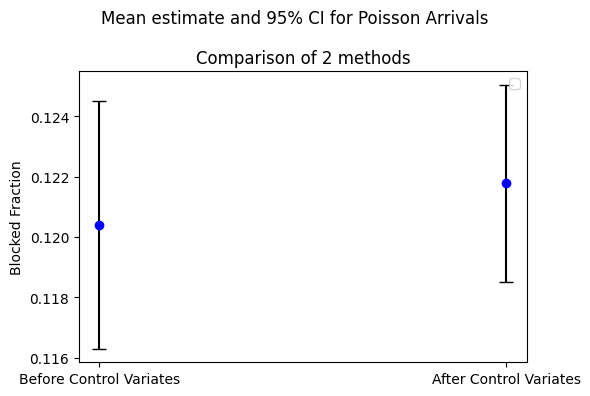

In [53]:
methods = ["Before Control Variates", "After Control Variates"]
estimates = [mean_blocked, mean_Y]
ci_lower = [ci_low, ci_low_Y]
ci_upper = [ci_high, ci_high_Y]

lower_errors = np.array(estimates) - np.array(ci_lower)
upper_errors = np.array(ci_upper) - np.array(estimates)

error = [lower_errors, upper_errors]


x_pos = np.arange(len(methods))

plt.figure(figsize=(6, 4))
plt.errorbar(
    x_pos,
    estimates,
    yerr=error,
    fmt='o',
    capsize=5,
    ecolor='black',
    color='blue'
)

plt.xticks(x_pos, methods)
plt.ylabel("Blocked Fraction")
plt.title("Comparison of 2 methods")
plt.suptitle("Mean estimate and 95% CI for Poisson Arrivals")
plt.legend()

plt.tight_layout()
plt.show()


### Part 6 of Exercise 5: Common Random Number Effect : DISCARDED

In [ ]:
N = TARGET_CUSTOMERS

U_arrivals = np.random.rand(N)      # for arrival times
U_service  = np.random.rand(N)      # for service times

Changes to th code

In [46]:
# Modification of interarrival times
def interarrival_poisson_from_U(U):
    return -np.log(1 - U) / LAMBDA_A

def interarrival_hyperexp_from_U(U):
    # U1 decides branch, U2 decides exponential
    if U < 0.8:
        return -np.log(1 - U) / 0.8333
    else:
        return -np.log(1 - U) / 5.0

def service_time_from_U(U):
    return -np.log(1 - U) * MEAN_SERVICE_TIME[selected_time]


def arrival_generator_CRN(env, system, stats, model, U_arrivals, U_service):
    customer_id = 0
    while customer_id < TARGET_CUSTOMERS:

        U = U_arrivals[customer_id]

        if model == "poisson":
            inter_arrival = interarrival_poisson_from_U(U)
        elif model == "hyperexp":
            inter_arrival = interarrival_hyperexp_from_U(U)

        yield env.timeout(inter_arrival)

        stats["total"] += 1   # <-- MISSING LINE (now fixed)

        env.process(customer_process_CRN(
            env, f"C_{customer_id}", system, stats, U_service[customer_id]
        ))

        customer_id += 1

    
def customer_process_CRN(env, name, system, stats, U):
    if system.count < system.capacity:
        with system.request() as req:
            yield req
            service_time = service_time_from_U(U)
            stats["service_times"].append(service_time)
            yield env.timeout(service_time)
    else:
        stats["blocked"] += 1



# single simulation script
def run_simulation_CRN(model, U_arrivals, U_service):
    env = simpy.Environment()
    system = simpy.Resource(env, capacity=M)

    stats = {"total": 0, "blocked": 0, "service_times": []}

    env.process(arrival_generator_CRN(env, system, stats, model, U_arrivals, U_service))
    env.run(until=TARGET_CUSTOMERS * 2)

    blocked_fraction = stats["blocked"] / stats["total"]
    empirical_mean_service = np.mean(stats["service_times"])

    return blocked_fraction, empirical_mean_service


In [49]:
# Store results
poisson_results = []
hyperexp_results = []

for i in range(REPLICATIONS):

    np.random.seed(42 + i)
    U_arrivals = np.random.rand(TARGET_CUSTOMERS)
    U_service  = np.random.rand(TARGET_CUSTOMERS)

    # Poisson
    blocked_poisson, _ = run_simulation_CRN("poisson", U_arrivals, U_service)
    poisson_results.append(blocked_poisson)

    # Hyperexponential
    blocked_hyper, _ = run_simulation_CRN("hyperexp", U_arrivals, U_service)
    hyperexp_results.append(blocked_hyper)

    print(f"Rep {i+1}: Poisson={blocked_poisson:.4f}, Hyperexp={blocked_hyper:.4f}")

Rep 1: Poisson=0.1320, Hyperexp=0.2858
Rep 2: Poisson=0.1116, Hyperexp=0.2682
Rep 3: Poisson=0.1187, Hyperexp=0.2715
Rep 4: Poisson=0.1245, Hyperexp=0.2818
Rep 5: Poisson=0.1119, Hyperexp=0.2716
Rep 6: Poisson=0.1128, Hyperexp=0.2691
Rep 7: Poisson=0.1223, Hyperexp=0.2749
Rep 8: Poisson=0.1234, Hyperexp=0.2742
Rep 9: Poisson=0.1190, Hyperexp=0.2629
Rep 10: Poisson=0.1255, Hyperexp=0.2821


In [ ]:
poisson_results = np.array(poisson_results)
hyperexp_results = np.array(hyperexp_results)

differences = hyperexp_results - poisson_results

# Means
mean_poisson = np.mean(poisson_results)
mean_hyper   = np.mean(hyperexp_results)
mean_diff    = np.mean(differences)

# Variances
var_poisson = np.var(poisson_results, ddof=1)
var_hyper   = np.var(hyperexp_results, ddof=1)
var_diff    = np.var(differences, ddof=1)

# CI
SE_p = np.sqrt(var_poisson / REPLICATIONS)
SE_h = np.sqrt(var_hyper   / REPLICATIONS)
SE_d = np.sqrt(var_diff    / REPLICATIONS)

ci_p = (mean_poisson - t_crit * SE_p, mean_poisson + t_crit * SE_p)
ci_h = (mean_hyper   - t_crit * SE_h, mean_hyper   + t_crit * SE_h)
ci_d = (mean_diff    - t_crit * SE_d, mean_diff    + t_crit * SE_d)

print("\n===== CRN SUMMARY =====")
print(f"Poisson Mean Blocked:       {mean_poisson:.6f}")
print(f"Poisson Variance:           {var_poisson:.8f}")
print(f"Poisson 95% CI:             [{ci_p[0]:.6f}, {ci_p[1]:.6f}]")

print(f"\nHyperexp Mean Blocked:      {mean_hyper:.6f}")
print(f"Hyperexp Variance:          {var_hyper:.8f}")
print(f"Hyperexp 95% CI:            [{ci_h[0]:.6f}, {ci_h[1]:.6f}]")

print(f"\nDifference Mean (H - P):    {mean_diff:.6f}")
print(f"Difference Variance:        {var_diff:.8f}")
print(f"Difference 95% CI:          [{ci_d[0]:.6f}, {ci_d[1]:.6f}]")

print(f"\nVariance Reduction (CRN):   {var_poisson + var_hyper:.6f} → {var_diff:.6f}")
print("=========================")

# The variance reduction factor is ~5x
# Both models in this setup see the same arrival and service randomness
# This is a key advantage of using CRN for simulation because it allows for more accurate comparisons between different models.
# Hyperexponential arrivals cause much higher blockage rates compared to Poisson arrivals.


===== CRN SUMMARY =====
Poisson Mean Blocked:       0.120170
Poisson Variance:           0.00004464
Poisson 95% CI:             [0.115391, 0.124949]

Hyperexp Mean Blocked:      0.274210
Hyperexp Variance:          0.00005100
Hyperexp 95% CI:            [0.269102, 0.279318]

Difference Mean (H - P):    0.154040
Difference Variance:        0.00001976
Difference 95% CI:          [0.150860, 0.157220]

Variance Reduction (CRN):   0.000096 → 0.000020


/var/folders/g6/d93by81s77b0lq36mrl7nv8m0000gn/T/ipykernel_34335/3609186759.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


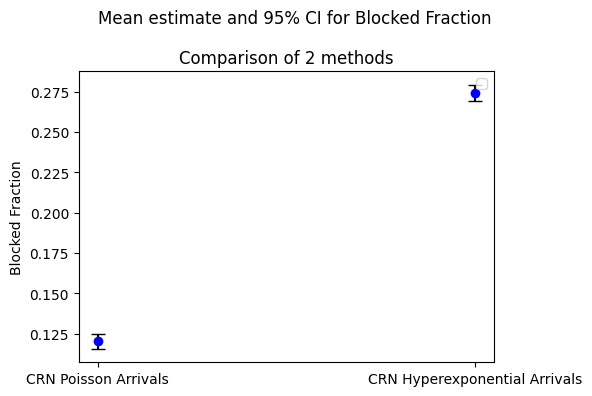

In [52]:
methods = ["CRN Poisson Arrivals", "CRN Hyperexponential Arrivals"]
estimates = [mean_poisson, mean_hyper]
ci_lower = [ci_p[0], ci_h[0]]
ci_upper = [ci_p[1], ci_h[1]]

lower_errors = np.array(estimates) - np.array(ci_lower)
upper_errors = np.array(ci_upper) - np.array(estimates)

error = [lower_errors, upper_errors]


x_pos = np.arange(len(methods))

plt.figure(figsize=(6, 4))
plt.errorbar(
    x_pos,
    estimates,
    yerr=error,
    fmt='o',
    capsize=5,
    ecolor='black',
    color='blue'
)

plt.xticks(x_pos, methods)
plt.ylabel("Blocked Fraction")
plt.title("Comparison of 2 methods")
plt.suptitle("Mean estimate and 95% CI for Blocked Fraction")
plt.legend()

plt.tight_layout()
plt.show()
